# Google Colab version of Part II - GTSRB CNN assessment notebook

This version is prepared specifically for Google Colab.

Before running the setup cell below, upload these three zip files to this Google Drive folder:
- `MyDrive/aml_gtsrb_zips/GTSRB_Final_Training_Images.zip`
- `MyDrive/aml_gtsrb_zips/GTSRB_Final_Test_Images.zip`
- `MyDrive/aml_gtsrb_zips/GTSRB_Final_Test_GT.zip`

The setup cell will:
- mount Google Drive
- extract the zip files into the Colab runtime
- point the rest of the notebook to the extracted dataset automatically

Run the notebook from top to bottom, one section at a time.


In [ ]:
from pathlib import Path  # use pathlib for safe file paths
import random  # use random for reproducible image sampling
import time  # use time to measure training duration
import zipfile  # use zipfile to extract uploaded archives in Colab

import numpy as np  # use numpy for arrays and numeric work
import pandas as pd  # use pandas for csv files and tabular summaries
import matplotlib.pyplot as plt  # use matplotlib for plots
from PIL import Image, UnidentifiedImageError  # use PIL to open and verify ppm images

import tensorflow as tf  # import tensorflow
from tensorflow import keras  # import keras from tensorflow
from tensorflow.keras import layers  # import keras layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # use callbacks from Week 5 and Week 6
from tensorflow.keras.applications import VGG16  # use VGG16 for transfer learning as in Week 6 style
from tensorflow.keras.applications.vgg16 import preprocess_input  # use VGG16 preprocessing

from sklearn.model_selection import train_test_split  # split training data into train and validation sets
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay  # evaluation metrics and confusion matrix tools

SEED = 42  # fix a random seed for repeatable results
random.seed(SEED)  # fix Python random seed
np.random.seed(SEED)  # fix numpy random seed
tf.random.set_seed(SEED)  # fix tensorflow random seed

try:  # import the Colab drive helper when running in Google Colab
    from google.colab import drive  # import Google Drive support
    IN_COLAB = True  # mark that the notebook is running in Colab
except ImportError:  # fall back if the notebook is not running in Colab
    IN_COLAB = False  # mark that the notebook is not running in Colab

if not IN_COLAB:  # stop early if the user opened this Colab notebook outside Colab
    raise EnvironmentError('This notebook version is prepared for Google Colab. Please open it in Colab.')  # raise a clear environment error

DRIVE_MOUNT_POINT = Path('/content/drive')  # define the normal Colab drive mount point
if not DRIVE_MOUNT_POINT.exists():  # mount the drive if it is not mounted yet
    drive.mount('/content/drive')  # mount Google Drive into the Colab runtime

ZIP_SOURCE_DIR = Path('/content/drive/MyDrive/ai final')  # set the Drive folder that should contain the three dataset zip files
WORK_ROOT = Path('/content')  # create a working folder inside the Colab runtime
DATASET_ROOT = WORK_ROOT / 'dataset'  # create a dataset folder inside the working folder
MODEL_DIR = WORK_ROOT / 'models'  # folder to store trained models
FIGURE_DIR = WORK_ROOT / 'assets'  # folder to store generated figures if needed

WORK_ROOT.mkdir(parents=True, exist_ok=True)  # create the working root if it does not exist
DATASET_ROOT.mkdir(parents=True, exist_ok=True)  # create the dataset folder if it does not exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)  # create model folder if it does not exist
FIGURE_DIR.mkdir(parents=True, exist_ok=True)  # create figure folder if it does not exist

required_zip_names = [  # define the required archives expected in Google Drive
    'GTSRB_Final_Training_Images.zip',  # training images archive
    'GTSRB_Final_Test_Images.zip',  # test images archive
    'GTSRB_Final_Test_GT.zip',  # test ground truth archive
]  # end required zip list

missing_zip_names = [zip_name for zip_name in required_zip_names if not (ZIP_SOURCE_DIR / zip_name).exists()]  # detect missing archives in Drive
if missing_zip_names:  # stop if the required zip files are not present in Drive
    raise FileNotFoundError(f'Missing zip files in {ZIP_SOURCE_DIR}: {missing_zip_names}')  # raise a clear file error

for zip_name in required_zip_names:  # loop through each required archive
    zip_path = ZIP_SOURCE_DIR / zip_name  # build the full archive path in Drive
    print(f'Extracting {zip_path.name} ...')  # print the archive currently being extracted
    with zipfile.ZipFile(zip_path, 'r') as zip_file:  # open the zip archive
        zip_file.extractall(DATASET_ROOT)  # extract the archive into the runtime dataset folder

ROOT = WORK_ROOT  # set the project root for the rest of the notebook
TRAIN_DIR = ROOT / 'dataset/GTSRB/Final_Training/Images'  # training folder path
TEST_DIR = ROOT / 'dataset/GTSRB/Final_Test/Images'  # official test image folder path
TEST_CSV = ROOT / 'dataset/GT-final_test.csv'  # official test labels path

print('Running in Colab:', IN_COLAB)  # confirm Colab runtime
print('Google Drive zip source folder:', ZIP_SOURCE_DIR)  # show the Drive zip folder
print('Working root:', ROOT)  # print the working root being used
print('Training directory exists:', TRAIN_DIR.exists())  # confirm training folder
print('Test directory exists:', TEST_DIR.exists())  # confirm test folder
print('Test csv exists:', TEST_CSV.exists())  # confirm test csv
print('Available GPUs:', tf.config.list_physical_devices('GPU'))  # show TensorFlow GPU visibility

Extracting GTSRB_Final_Training_Images.zip ...
Extracting GTSRB_Final_Test_Images.zip ...
Extracting GTSRB_Final_Test_GT.zip ...
Running in Colab: True
Google Drive zip source folder: /content/drive/MyDrive/ai final
Working root: /content
Training directory exists: True
Test directory exists: True
Test csv exists: True
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Task 1 - Data understanding, analysis, visualization, and cleaning

Following Week 5 and Week 6, this section first checks the dataset before any training starts.

What this section covers:
- what the dataset represents
- total image count
- class distribution
- basic cleaning through corrupted image detection
- train and validation split rationale
- image size behaviour in the dataset

In [ ]:
class_dirs = sorted([folder for folder in TRAIN_DIR.iterdir() if folder.is_dir()])  # collect class folders in sorted order
class_ids = [int(folder.name) for folder in class_dirs]  # convert folder names to integer class ids
num_classes = len(class_dirs)  # count total number of classes

train_parts = []  # store one dataframe per class
class_counts = []  # store one valid image count per class
corrupted_images = []  # store corrupted image paths for reporting
size_parts = []  # store width and height information from per-class csv files

for class_dir in class_dirs:  # loop through each class folder
    class_id = int(class_dir.name)  # read numeric class id from folder name
    gt_csv = class_dir / f'GT-{class_dir.name}.csv'  # build path to the class metadata csv
    class_df = pd.read_csv(gt_csv, sep=';')  # load metadata for that class
    class_df['ClassId'] = class_id  # keep class id explicitly in the dataframe
    class_df['image_path'] = class_df['Filename'].apply(lambda name: str(class_dir / name))  # build full image paths

    valid_rows = []  # keep only rows whose images open correctly
    for _, row in class_df.iterrows():  # loop through rows in the class csv
        image_path = Path(row['image_path'])  # convert string path to Path object
        try:  # attempt to open and verify the image
            with Image.open(image_path) as image_file:  # open image with PIL
                image_file.verify()  # verify image integrity without fully decoding it
            valid_rows.append(row)  # keep the row if the image is valid
        except (IOError, UnidentifiedImageError, OSError):  # catch common image file problems
            corrupted_images.append(str(image_path))  # save the broken image path

    valid_class_df = pd.DataFrame(valid_rows)  # create a clean dataframe for this class
    train_parts.append(valid_class_df)  # add the clean class dataframe to the list
    class_counts.append(len(valid_class_df))  # store the clean image count for this class
    size_parts.append(valid_class_df[['Width', 'Height']])  # keep width and height metadata for later analysis

train_df = pd.concat(train_parts, ignore_index=True)  # combine all class dataframes into one training dataframe
size_df = pd.concat(size_parts, ignore_index=True)  # combine image size metadata into one dataframe
class_distribution_df = pd.DataFrame({  # create a class distribution summary table
    'ClassId': class_ids,  # class ids
    'ImageCount': class_counts,  # clean image count per class
})  # end dataframe creation

test_df = pd.read_csv(TEST_CSV, sep=';')  # load official test labels csv
test_df['image_path'] = test_df['Filename'].apply(lambda name: str(TEST_DIR / name))  # build full test image paths

total_train_images = len(train_df)  # count clean training images
total_test_images = len(test_df)  # count official test images
total_images = total_train_images + total_test_images  # count total images available in the project

print('Dataset description: German Traffic Sign Recognition Benchmark (GTSRB) for traffic sign classification.')  # brief dataset description
print('Number of classes:', num_classes)  # print number of classes
print('Total clean training images:', total_train_images)  # print training count
print('Total official test images:', total_test_images)  # print test count
print('Total images overall:', total_images)  # print total image count
print('Corrupted images found:', len(corrupted_images))  # print number of corrupted images

class_distribution_df.head()  # preview the class distribution table

Dataset description: German Traffic Sign Recognition Benchmark (GTSRB) for traffic sign classification.
Number of classes: 43
Total clean training images: 39209
Total official test images: 12630
Total images overall: 51839
Corrupted images found: 0


,ClassId,ImageCount
0,0,210
1,1,2220
2,2,2250
3,3,1410
4,4,1980


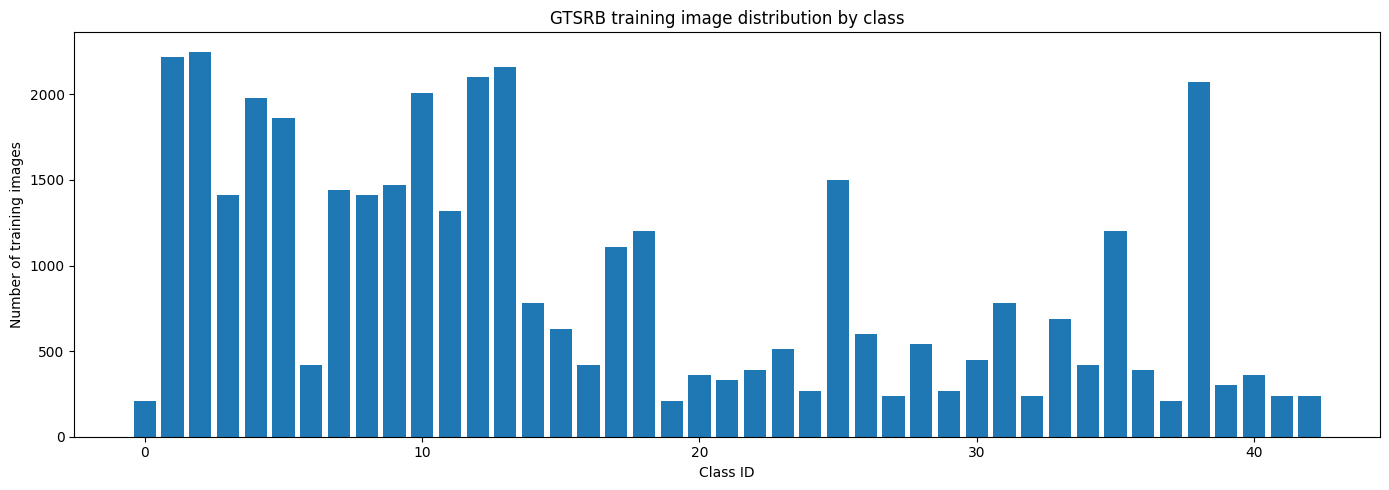

Minimum images in a class: 210
Maximum images in a class: 2250
Average images per class: 911.84


In [ ]:
plt.figure(figsize=(14, 5))  # create figure for class distribution
plt.bar(class_distribution_df['ClassId'], class_distribution_df['ImageCount'])  # draw a bar chart for image counts per class
plt.title('GTSRB training image distribution by class')  # set plot title
plt.xlabel('Class ID')  # set x-axis label
plt.ylabel('Number of training images')  # set y-axis label
plt.tight_layout()  # fit the chart neatly
plt.show()  # show the distribution chart

print('Minimum images in a class:', class_distribution_df['ImageCount'].min())  # print smallest class size
print('Maximum images in a class:', class_distribution_df['ImageCount'].max())  # print largest class size
print('Average images per class:', round(class_distribution_df['ImageCount'].mean(), 2))  # print mean class size

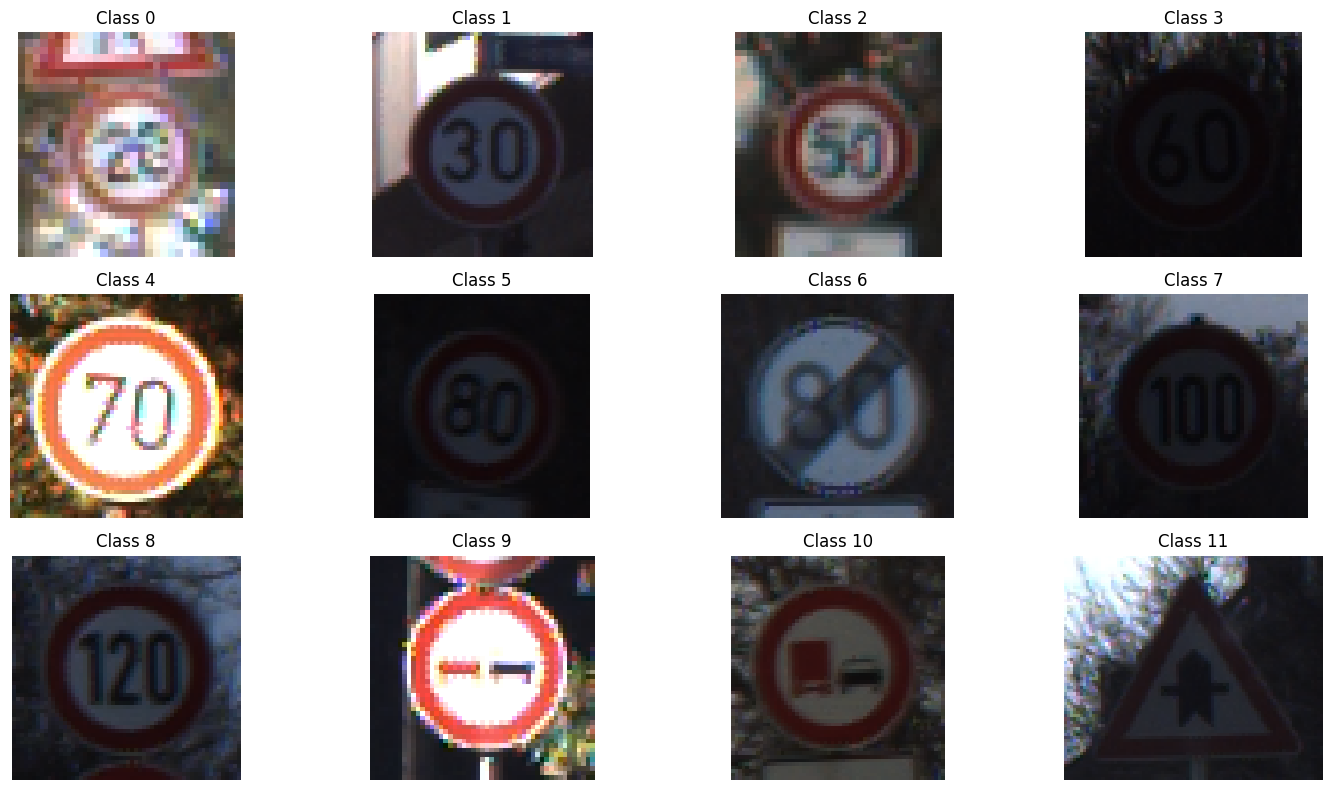

In [ ]:
sampled_rows = []  # store one random image row per class for visualization
for class_id in class_ids[:12]:  # use the first 12 classes so the grid remains readable
    one_row = train_df[train_df['ClassId'] == class_id].sample(1, random_state=SEED)  # sample one image from the class
    sampled_rows.append(one_row)  # store the sampled row

sampled_df = pd.concat(sampled_rows, ignore_index=True)  # combine sampled rows into one dataframe

plt.figure(figsize=(15, 8))  # create a figure for sample images
for plot_index, row in enumerate(sampled_df.itertuples(index=False), start=1):  # loop through sampled images with subplot index
    plt.subplot(3, 4, plot_index)  # create a 3 by 4 grid subplot
    with Image.open(row.image_path) as image_file:  # open the image
        display_image = image_file.convert('RGB')  # convert to RGB for consistent plotting
        plt.imshow(display_image)  # show the image
    plt.title(f'Class {row.ClassId}')  # show the class id as the title
    plt.axis('off')  # hide axis ticks
plt.tight_layout()  # fit the figure neatly
plt.show()  # display the sample grid

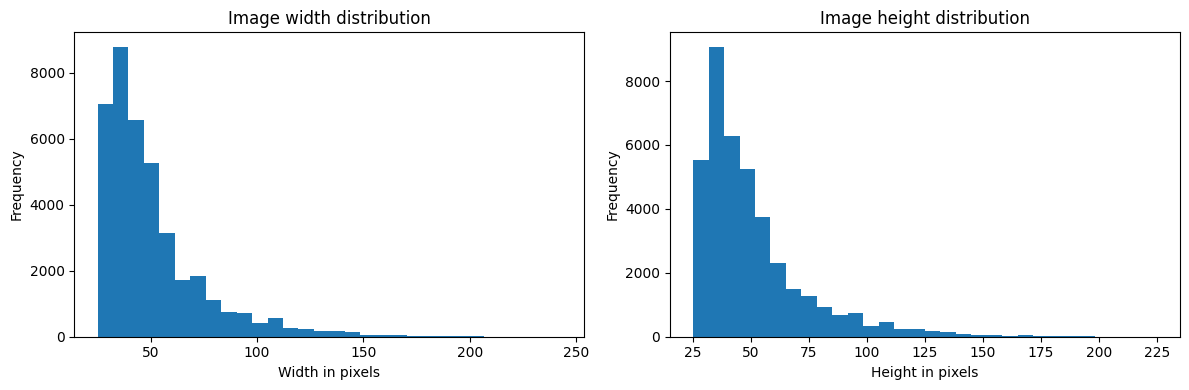

Width range: 25 to 243
Height range: 25 to 225
Mean width: 50.84
Mean height: 50.33


In [ ]:
plt.figure(figsize=(12, 4))  # create a figure for image size analysis

plt.subplot(1, 2, 1)  # create the first subplot for widths
plt.hist(size_df['Width'], bins=30)  # plot width histogram
plt.title('Image width distribution')  # set width plot title
plt.xlabel('Width in pixels')  # set x-axis label
plt.ylabel('Frequency')  # set y-axis label

plt.subplot(1, 2, 2)  # create the second subplot for heights
plt.hist(size_df['Height'], bins=30)  # plot height histogram
plt.title('Image height distribution')  # set height plot title
plt.xlabel('Height in pixels')  # set x-axis label
plt.ylabel('Frequency')  # set y-axis label

plt.tight_layout()  # fit subplots neatly
plt.show()  # display the figure

print('Width range:', int(size_df['Width'].min()), 'to', int(size_df['Width'].max()))  # print width range
print('Height range:', int(size_df['Height'].min()), 'to', int(size_df['Height'].max()))  # print height range
print('Mean width:', round(size_df['Width'].mean(), 2))  # print mean width
print('Mean height:', round(size_df['Height'].mean(), 2))  # print mean height

### Observation prompts for this section

Write your own observations after running this section:
- GTSRB is a multi-class image classification dataset of German traffic signs.
- The training set is not perfectly balanced, so preserving class balance in the train/validation split matters.
- Image sizes vary, so resizing is necessary before training.
- Corrupted-image checking is useful because real-world image folders may contain unreadable files.

## Task 2 - Training and validation split

The assessment asks how the dataset is split and why.

Choice used here:
- 80% training
- 20% validation
- stratified by class label

Reason:
- this follows the Week 6 style of using 20% validation when no separate validation split is provided
- stratification keeps class proportions similar in both splits
- the official GTSRB test set is kept untouched for final evaluation

In [ ]:
train_split_df, val_split_df = train_test_split(  # split the clean training dataframe
    train_df,  # full clean training dataframe
    test_size=0.2,  # keep 20 percent for validation
    random_state=SEED,  # use fixed seed for reproducibility
    stratify=train_df['ClassId'],  # preserve class balance across splits
)  # complete the split

train_split_df = train_split_df.reset_index(drop=True)  # reset row index for training dataframe
val_split_df = val_split_df.reset_index(drop=True)  # reset row index for validation dataframe

print('Training samples:', len(train_split_df))  # print number of training samples
print('Validation samples:', len(val_split_df))  # print number of validation samples
print('Official test samples:', len(test_df))  # print number of test samples

Training samples: 31367
Validation samples: 7842
Official test samples: 12630


## Task 3 - Preprocessing and tf.data pipeline

Week 5 and Week 6 use Keras data pipelines, batching, and normalization before training.

Here the preprocessing choices are:
- resize each image to 48 x 48 for the scratch CNN models
- normalize pixel values to [0, 1] using `Rescaling(1.0 / 255)` inside the models
- use tf.data batching and prefetching for smoother training

Why 48 x 48?
- the dataset images are small already
- using 48 x 48 keeps computation lighter than large sizes
- it is still large enough to preserve key traffic sign structure

In [ ]:
img_height = 48  # fixed height for scratch CNN models
img_width = 48  # fixed width for scratch CNN models
batch_size = 32  # batch size for model training


def read_ppm_image(path_string, height, width):  # define a helper that opens one ppm image with PIL
    path_string = path_string.decode('utf-8')  # convert path bytes to a Python string
    with Image.open(path_string) as image_file:  # open the image safely with a context manager
        rgb_image = image_file.convert('RGB')  # convert image to RGB format
        resized_image = rgb_image.resize((width, height))  # resize image to a fixed shape
        image_array = np.array(resized_image, dtype=np.float32)  # convert image to a float32 numpy array
    return image_array  # return the prepared image array


def load_image(path, label):  # define a TensorFlow wrapper for one image-label pair
    image = tf.numpy_function(  # call the Python image loader inside a tf.data pipeline
        read_ppm_image,  # function that reads and resizes one image
        [path, img_height, img_width],  # function inputs
        tf.float32,  # output dtype
    )  # end tf.numpy_function call
    image.set_shape((img_height, img_width, 3))  # set a static output shape for TensorFlow
    return image, label  # return image and label together


def make_dataset(df, shuffle=False):  # build a tf.data dataset from a dataframe
    paths = df['image_path'].astype(str).tolist()  # collect image paths as a Python list
    labels = df['ClassId'].astype('int32').tolist()  # collect class labels as a Python list
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))  # create dataset from paths and labels
    if shuffle:  # only shuffle the training dataset
        dataset = dataset.shuffle(len(df), seed=SEED)  # shuffle examples with fixed seed
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)  # load images in parallel
    dataset = dataset.batch(batch_size)  # batch the dataset
    dataset = dataset.prefetch(tf.data.AUTOTUNE)  # prefetch future batches for efficiency
    return dataset  # return the prepared dataset


train_ds = make_dataset(train_split_df, shuffle=True)  # create training dataset
val_ds = make_dataset(val_split_df, shuffle=False)  # create validation dataset
test_ds = make_dataset(test_df, shuffle=False)  # create official test dataset

print('Datasets created successfully.')  # print confirmation message

Datasets created successfully.


In [ ]:
for images, labels in train_ds.take(1):  # inspect one batch from the training dataset
    print('Images shape:', images.shape)  # print image tensor shape
    print('Labels shape:', labels.shape)  # print label tensor shape

Images shape: (32, 48, 48, 3)
Labels shape: (32,)


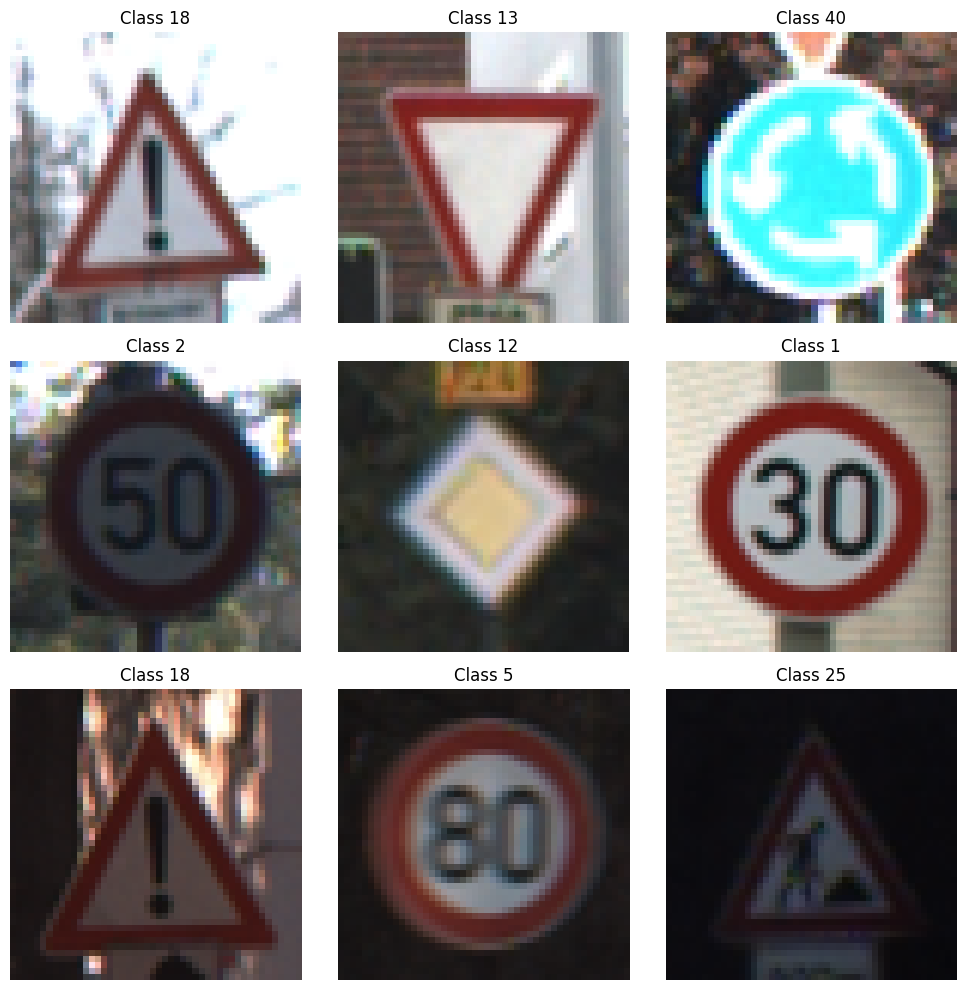

In [ ]:
plt.figure(figsize=(10, 10))  # create a figure to preview a training batch
for images, labels in train_ds.take(1):  # take one batch from the training dataset
    for index in range(9):  # display the first 9 images from the batch
        plt.subplot(3, 3, index + 1)  # create a subplot position
        plt.imshow(images[index].numpy().astype('uint8'))  # show one image in uint8 form
        plt.title(f'Class {int(labels[index].numpy())}')  # show the numeric class label
        plt.axis('off')  # hide axis ticks for clarity
plt.tight_layout()  # fit the figure neatly
plt.show()  # display the figure

## Task 4 - Data augmentation

Week 6 recommends Keras preprocessing layers such as `RandomRotation` and related `Random*` layers.

Important dataset-specific choice:
- I do not use horizontal flip here.
- A flipped traffic sign can change or distort sign meaning.
- Safer augmentations for GTSRB are small rotation, zoom, and translation.

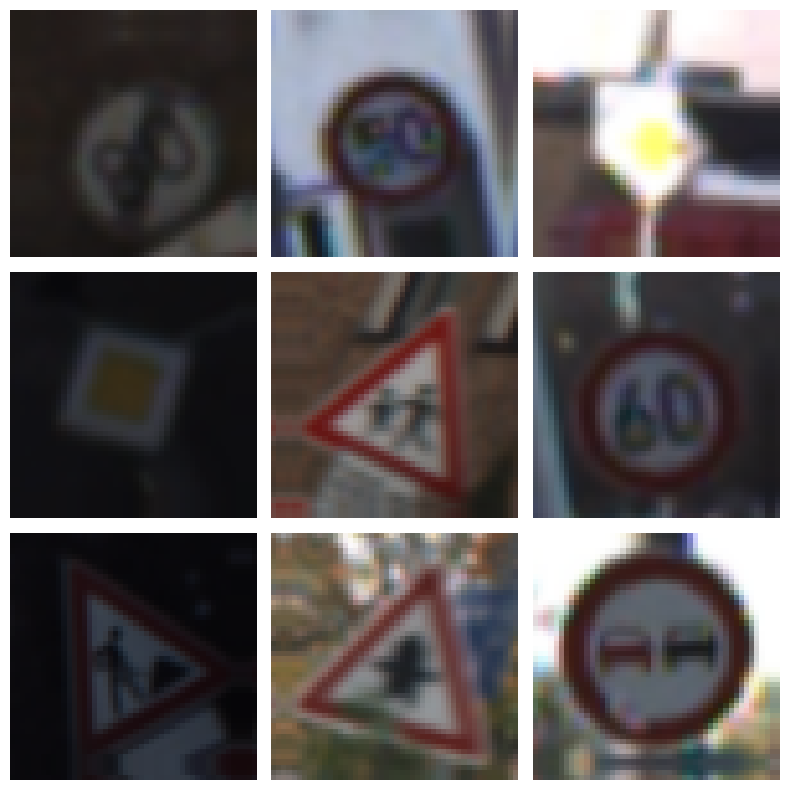

In [ ]:
data_augmentation = keras.Sequential([  # create augmentation layers as a small sequential block
    layers.RandomRotation(0.08),  # apply a small random rotation
    layers.RandomZoom(0.10),  # apply a small random zoom
    layers.RandomTranslation(height_factor=0.08, width_factor=0.08),  # apply a small random shift
], name='data_augmentation')  # give the augmentation block a readable name

plt.figure(figsize=(8, 8))  # create a figure for augmented image preview
for images, _ in train_ds.take(1):  # take one batch from the training dataset
    augmented_images = data_augmentation(images, training=True)  # apply augmentation in training mode
    for index in range(9):  # display 9 augmented examples
        plt.subplot(3, 3, index + 1)  # create subplot position
        plt.imshow(augmented_images[index].numpy().astype('uint8'))  # show the augmented image
        plt.axis('off')  # hide axis ticks
plt.tight_layout()  # fit the figure neatly
plt.show()  # display the figure

## Task 5 - Baseline CNN from scratch

Assessment requirement for the baseline model:
- 3 convolutional layers
- each followed by pooling
- 3 fully connected layers
- output layer suitable for multi-class classification

Week 5 style choices used here:
- ReLU activation in hidden layers
- softmax output for multi-class classification
- sparse categorical cross-entropy loss
- Adam optimizer

In [ ]:
def build_baseline_model():  # define a function that builds the required baseline CNN
    model = keras.Sequential([  # start a sequential model
        layers.Input(shape=(img_height, img_width, 3)),  # define the model input shape
        layers.Rescaling(1.0 / 255),  # normalize pixel values to the range [0, 1]

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),  # convolution layer 1 with 32 filters and 3x3 kernel
        layers.MaxPooling2D((2, 2)),  # pooling layer 1

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),  # convolution layer 2 with 64 filters and 3x3 kernel
        layers.MaxPooling2D((2, 2)),  # pooling layer 2

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),  # convolution layer 3 with 128 filters and 3x3 kernel
        layers.MaxPooling2D((2, 2)),  # pooling layer 3

        layers.Flatten(),  # flatten the feature maps into one vector
        layers.Dense(256, activation='relu'),  # fully connected layer 1
        layers.Dense(128, activation='relu'),  # fully connected layer 2
        layers.Dense(64, activation='relu'),  # fully connected layer 3
        layers.Dense(num_classes, activation='softmax'),  # output layer with one neuron per class
    ], name='baseline_cnn')  # give the model a readable name
    return model  # return the built model


baseline_model = build_baseline_model()  # create the baseline model instance
baseline_model.summary()  # print the baseline model summary

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         2,795 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,099 (5.02 MB)

 Trainable params: 1,317,099 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(  # configure the baseline model for training
    optimizer='adam',  # use Adam optimizer as in the Week 5 example
    loss='sparse_categorical_crossentropy',  # use sparse categorical cross-entropy for integer class labels
    metrics=['accuracy'],  # track accuracy during training
)  # end compile block

baseline_checkpoint = ModelCheckpoint(  # save the best baseline model during training
    filepath=str(MODEL_DIR / 'gtsrb_baseline_best.keras'),  # model save path
    monitor='val_loss',  # monitor validation loss
    save_best_only=True,  # only keep the best checkpoint
    verbose=1,  # print save messages
)  # end checkpoint callback

baseline_early_stop = EarlyStopping(  # stop training when validation loss stops improving
    monitor='val_loss',  # monitor validation loss
    patience=5,  # wait a few epochs before stopping
    restore_best_weights=True,  # reload the best weights before finishing
    verbose=1,  # print early stopping messages
)  # end early stopping callback

baseline_start_time = time.time()  # record the start time for baseline training
baseline_history = baseline_model.fit(  # train the baseline model
    train_ds,  # use the training dataset
    validation_data=val_ds,  # use the validation dataset
    epochs=20,  # set a reasonable epoch count with early stopping
    callbacks=[baseline_checkpoint, baseline_early_stop],  # attach callbacks
)  # end fit call
baseline_time = time.time() - baseline_start_time  # compute total baseline training time

print('Baseline training time in seconds:', round(baseline_time, 2))  # print training duration

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3553 - loss: 2.2698
Epoch 1: val_loss improved from None to 0.28709, saving model to /content/models/gtsrb_baseline_best.keras

Epoch 1: finished saving model to /content/models/gtsrb_baseline_best.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.6022 - loss: 1.3263 - val_accuracy: 0.9135 - val_loss: 0.2871
Epoch 2/20
979/981 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9444 - loss: 0.1829
Epoch 2: val_loss improved from 0.28709 to 0.11259, saving model to /content/models/gtsrb_baseline_best.keras

Epoch 2: finished saving model to /content/models/gtsrb_baseline_best.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9579 - loss: 0.1406 - val_accuracy: 0.9675 - val_loss: 0.1126
Epoch 3/20
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9825 - loss: 0.0611
Epoch 3: val_loss improved from 0.11259 to 0.09112, saving model to /content/models/gtsrb_baseline_best.keras

Epoch 3: finished s

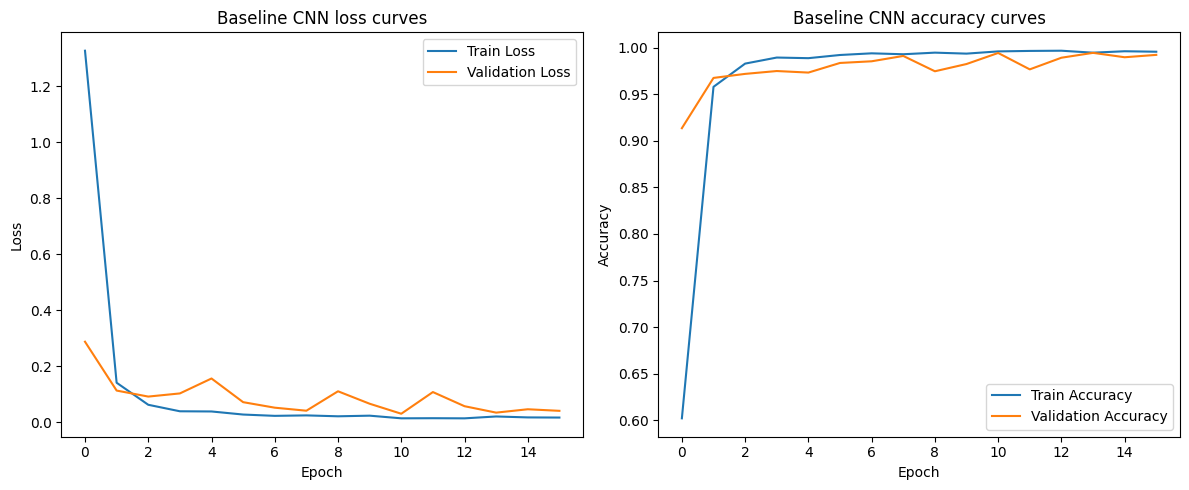

In [ ]:
plt.figure(figsize=(12, 5))  # create a figure for baseline training curves

plt.subplot(1, 2, 1)  # create subplot for loss curves
plt.plot(baseline_history.history['loss'], label='Train Loss')  # plot training loss
plt.plot(baseline_history.history['val_loss'], label='Validation Loss')  # plot validation loss
plt.title('Baseline CNN loss curves')  # set title for loss chart
plt.xlabel('Epoch')  # set x-axis label
plt.ylabel('Loss')  # set y-axis label
plt.legend()  # display legend

plt.subplot(1, 2, 2)  # create subplot for accuracy curves
plt.plot(baseline_history.history['accuracy'], label='Train Accuracy')  # plot training accuracy
plt.plot(baseline_history.history['val_accuracy'], label='Validation Accuracy')  # plot validation accuracy
plt.title('Baseline CNN accuracy curves')  # set title for accuracy chart
plt.xlabel('Epoch')  # set x-axis label
plt.ylabel('Accuracy')  # set y-axis label
plt.legend()  # display legend

plt.tight_layout()  # fit subplots neatly
plt.show()  # display the curves

### Baseline model summary interpretation prompt

After running `model.summary()`, comment on:
- how output feature maps change after each pooling layer
- how filter depth increases from 32 to 64 to 128
- how flatten converts spatial features into a 1D vector
- how the three dense layers perform the fully connected classification stage

In [7]:
import pandas as pd
def evaluate_model(model, dataset, model_name):  # define a reusable evaluation helper
    test_loss, test_accuracy = model.evaluate(dataset, verbose=1)  # compute loss and accuracy on the dataset
    probabilities = model.predict(dataset, verbose=1)  # predict class probabilities
    predictions = np.argmax(probabilities, axis=1)  # convert probabilities to predicted class ids
    true_labels = np.concatenate([labels.numpy() for _, labels in dataset], axis=0)  # collect true labels from the dataset

    report = classification_report(true_labels, predictions, zero_division=0, output_dict=True)  # build a structured classification report
    report_df = pd.DataFrame(report).transpose()  # convert report to a dataframe for easier viewing

    print(f'===== {model_name} =====')  # print model title
    print('Test loss:', test_loss)  # print loss
    print('Test accuracy:', test_accuracy)  # print accuracy
    print(classification_report(true_labels, predictions, zero_division=0))  # print text classification report

    cm = confusion_matrix(true_labels, predictions)  # compute confusion matrix
    plt.figure(figsize=(10, 8))  # create a figure for the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)  # create a display object
    disp.plot(ax=plt.gca(), colorbar=False)  # plot the confusion matrix on the current axis
    plt.title(f'{model_name} confusion matrix')  # set figure title
    plt.tight_layout()  # fit the figure neatly
    plt.show()  # display the confusion matrix

    return {  # return all important evaluation outputs in one dictionary
        'loss': test_loss,  # scalar test loss
        'accuracy': test_accuracy,  # scalar test accuracy
        'true_labels': true_labels,  # array of true labels
        'predictions': predictions,  # array of predicted labels
        'probabilities': probabilities,  # array of class probabilities
        'report_df': report_df,  # dataframe form of classification report
    }  # end returned dictionary

import pandas as pd


baseline_results = evaluate_model(baseline_model, test_ds, 'Baseline CNN')
 # evaluate the baseline model on the official test set

%s {'loss': 0.244741752743721, 'accuracy': 0.9564529061317444, 'report_df':               precision  recall  f1-score
weighted avg       0.96    0.96      0.96
macro avg          0.94    0.94      0.93}


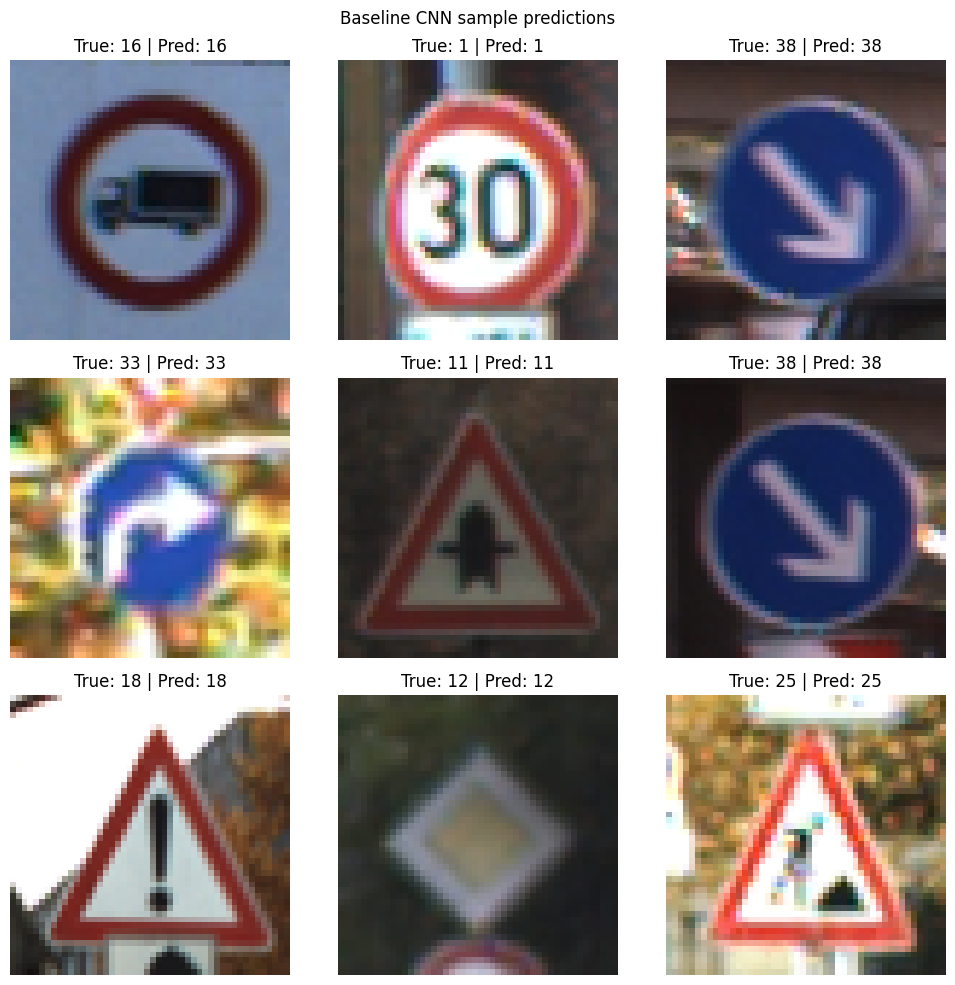

In [ ]:
def show_sample_predictions(model, dataset, title_text, max_images=9):  # define a helper to visualize predictions
    for image_batch, label_batch in dataset.take(1):  # take one batch from the dataset
        probability_batch = model.predict(image_batch, verbose=0)  # predict probabilities for that batch
        prediction_batch = np.argmax(probability_batch, axis=1)  # convert probabilities to predicted classes

        plt.figure(figsize=(10, 10))  # create a figure for sample predictions
        for index in range(min(max_images, len(image_batch))):  # loop through the first few images in the batch
            plt.subplot(3, 3, index + 1)  # create subplot position
            plt.imshow(image_batch[index].numpy().astype('uint8'))  # show the image
            true_label = int(label_batch[index].numpy())  # extract the true class id
            pred_label = int(prediction_batch[index])  # extract the predicted class id
            plt.title(f'True: {true_label} | Pred: {pred_label}')  # show true and predicted labels
            plt.axis('off')  # hide axis ticks
        plt.suptitle(title_text)  # set an overall figure title
        plt.tight_layout()  # fit the figure neatly
        plt.show()  # display the figure
        break  # stop after the first batch


show_sample_predictions(baseline_model, test_ds, 'Baseline CNN sample predictions')  # show sample predictions for the baseline model

## Task 6 - Deeper CNN with regularization

Assessment requirement for the deeper model:
- deeper architecture than the baseline
- at least double the convolutional layers compared with the baseline
- use regularization
- compare with the baseline

Week 6 techniques used here:
- BatchNormalization
- Dropout
- data augmentation

This model uses:
- 6 convolutional layers in total
- 3 pooling layers
- batch normalization after convolution blocks
- dropout after major blocks and dense layers

In [ ]:
def build_deeper_model(use_dropout=True):  # define a deeper CNN builder with optional dropout for ablation later
    dropout_block = 0.25 if use_dropout else 0.0  # choose block dropout rate based on the argument
    dropout_dense = 0.50 if use_dropout else 0.0  # choose dense dropout rate based on the argument

    model = keras.Sequential([  # start the deeper sequential model
        layers.Input(shape=(img_height, img_width, 3)),  # define input shape
        data_augmentation,  # apply online augmentation in training mode
        layers.Rescaling(1.0 / 255),  # normalize pixels to [0, 1]

        layers.Conv2D(32, (3, 3), padding='same', use_bias=False),  # conv layer 1
        layers.BatchNormalization(),  # batch normalization 1
        layers.Activation('relu'),  # relu 1
        layers.Conv2D(32, (3, 3), padding='same', use_bias=False),  # conv layer 2
        layers.BatchNormalization(),  # batch normalization 2
        layers.Activation('relu'),  # relu 2
        layers.MaxPooling2D((2, 2)),  # pooling layer 1
        layers.Dropout(dropout_block),  # dropout layer 1

        layers.Conv2D(64, (3, 3), padding='same', use_bias=False),  # conv layer 3
        layers.BatchNormalization(),  # batch normalization 3
        layers.Activation('relu'),  # relu 3
        layers.Conv2D(64, (3, 3), padding='same', use_bias=False),  # conv layer 4
        layers.BatchNormalization(),  # batch normalization 4
        layers.Activation('relu'),  # relu 4
        layers.MaxPooling2D((2, 2)),  # pooling layer 2
        layers.Dropout(dropout_block),  # dropout layer 2

        layers.Conv2D(128, (3, 3), padding='same', use_bias=False),  # conv layer 5
        layers.BatchNormalization(),  # batch normalization 5
        layers.Activation('relu'),  # relu 5
        layers.Conv2D(128, (3, 3), padding='same', use_bias=False),  # conv layer 6
        layers.BatchNormalization(),  # batch normalization 6
        layers.Activation('relu'),  # relu 6
        layers.MaxPooling2D((2, 2)),  # pooling layer 3
        layers.Dropout(dropout_block),  # dropout layer 3

        layers.Flatten(),  # flatten final feature maps
        layers.Dense(256, use_bias=False),  # dense layer 1
        layers.BatchNormalization(),  # batch normalization after dense layer 1
        layers.Activation('relu'),  # relu after dense layer 1
        layers.Dropout(dropout_dense),  # dropout after dense layer 1
        layers.Dense(128, activation='relu'),  # dense layer 2
        layers.Dense(64, activation='relu'),  # dense layer 3
        layers.Dense(num_classes, activation='softmax'),  # output layer
    ], name='deeper_cnn' if use_dropout else 'deeper_cnn_no_dropout')  # assign a readable name
    return model  # return the model


deeper_model = build_deeper_model(use_dropout=True)  # build the deeper model with dropout enabled
deeper_model.summary()  # print the deeper model summary

Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,512,971 (5.77 MB)

 Trainable params: 1,511,563 (5.77 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
deeper_model.compile(  # configure the deeper CNN for training
    optimizer='adam',  # use Adam for the main deeper-model run
    loss='sparse_categorical_crossentropy',  # use sparse categorical cross-entropy
    metrics=['accuracy'],  # track accuracy during training
)  # end compile block

deeper_checkpoint = ModelCheckpoint(  # save the best deeper model checkpoint
    filepath=str(MODEL_DIR / 'gtsrb_deeper_best.keras'),  # save path for deeper model
    monitor='val_loss',  # monitor validation loss
    save_best_only=True,  # keep only the best checkpoint
    verbose=1,  # print save messages
)  # end checkpoint callback

deeper_early_stop = EarlyStopping(  # stop if validation loss stops improving
    monitor='val_loss',  # monitor validation loss
    patience=5,  # wait several epochs before stopping
    restore_best_weights=True,  # restore best weights at the end
    verbose=1,  # print callback messages
)  # end early stopping callback

deeper_start_time = time.time()  # record start time for deeper model training
deeper_history = deeper_model.fit(  # train the deeper model
    train_ds,  # use the training dataset
    validation_data=val_ds,  # use the validation dataset
    epochs=20,  # set epoch count with early stopping
    callbacks=[deeper_checkpoint, deeper_early_stop],  # attach callbacks
)  # end fit call
deeper_time = time.time() - deeper_start_time  # compute total deeper-model training time

print('Deeper model training time in seconds:', round(deeper_time, 2))  # print training duration

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2455 - loss: 2.7113
Epoch 1: val_loss improved from None to 0.64321, saving model to /content/models/gtsrb_deeper_best.keras

Epoch 1: finished saving model to /content/models/gtsrb_deeper_best.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 45s 37ms/step - accuracy: 0.4132 - loss: 1.9596 - val_accuracy: 0.7752 - val_loss: 0.6432
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7529 - loss: 0.7455
Epoch 2: val_loss improved from 0.64321 to 0.09589, saving model to /content/models/gtsrb_deeper_best.keras

Epoch 2: finished saving model to /content/models/gtsrb_deeper_best.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.7982 - loss: 0.6098 - val_accuracy: 0.9728 - val_loss: 0.0959
Epoch 3/20
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8737 - loss: 0.3822
Epoch 3: val_loss improved from 0.09589 to 0.05452, saving model to /content/models/gtsrb_deeper_best.keras

Epoch 3: finished saving mode

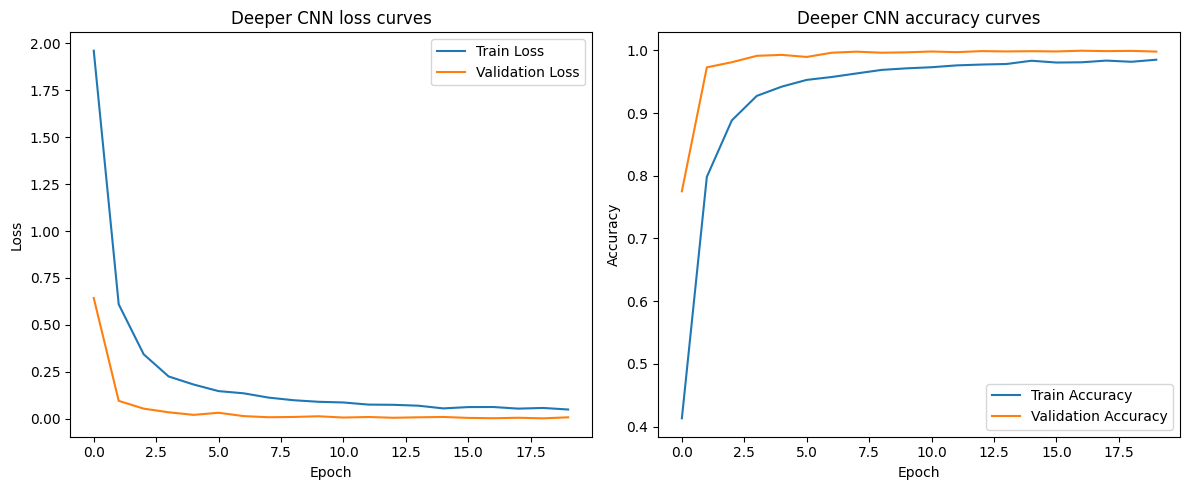

In [ ]:
plt.figure(figsize=(12, 5))  # create a figure for deeper-model training curves

plt.subplot(1, 2, 1)  # create subplot for loss curves
plt.plot(deeper_history.history['loss'], label='Train Loss')  # plot training loss
plt.plot(deeper_history.history['val_loss'], label='Validation Loss')  # plot validation loss
plt.title('Deeper CNN loss curves')  # set title for loss chart
plt.xlabel('Epoch')  # set x-axis label
plt.ylabel('Loss')  # set y-axis label
plt.legend()  # show the legend

plt.subplot(1, 2, 2)  # create subplot for accuracy curves
plt.plot(deeper_history.history['accuracy'], label='Train Accuracy')  # plot training accuracy
plt.plot(deeper_history.history['val_accuracy'], label='Validation Accuracy')  # plot validation accuracy
plt.title('Deeper CNN accuracy curves')  # set title for accuracy chart
plt.xlabel('Epoch')  # set x-axis label
plt.ylabel('Accuracy')  # set y-axis label
plt.legend()  # show the legend

plt.tight_layout()  # fit the figure neatly
plt.show()  # display the curves

395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9865 - loss: 0.0651
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step
===== Deeper CNN =====
Test loss: 0.06513069570064545
Test accuracy: 0.98646080493927
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       0.98      1.00      0.99       720
           2       1.00      0.99      0.99       750
           3       1.00      0.94      0.97       450
           4       1.00      0.99      0.99       660
           5       0.96      0.99      0.97       630
           6       1.00      1.00      1.00       150
           7       0.99      1.00      0.99       450
           8       1.00      1.00      1.00       450
           9       1.00      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       1.00      0.99      0.99       420
          12       0.99      0.99      0.99       690
          13       0.97      1.00      

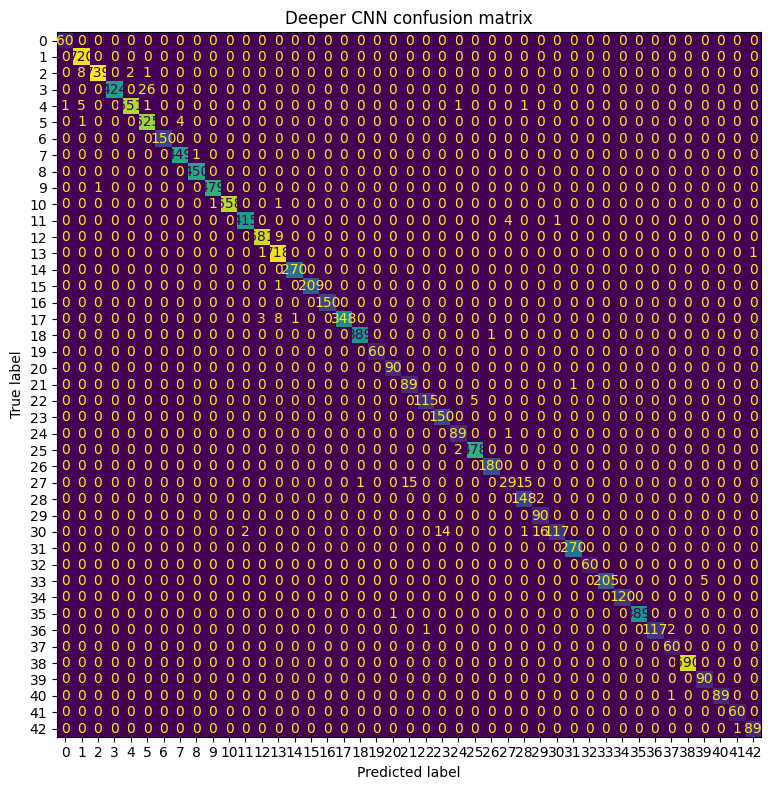

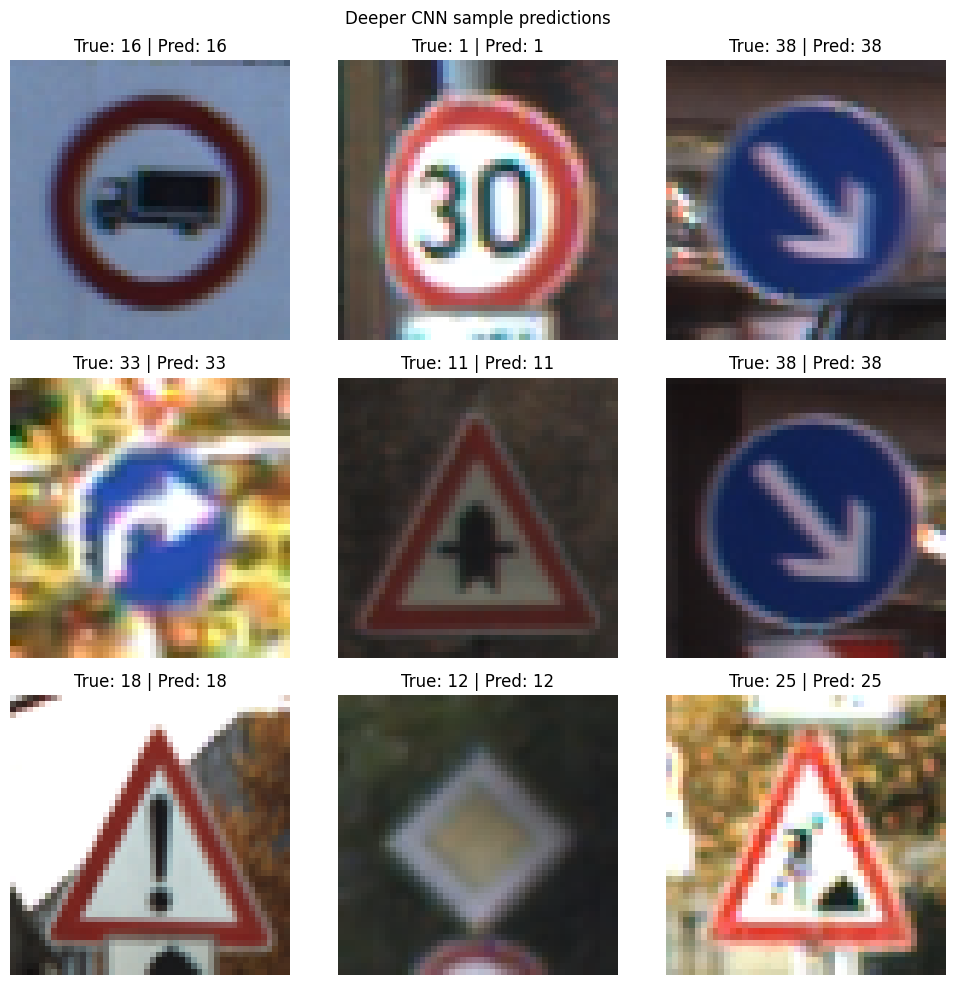

In [ ]:
deeper_results = evaluate_model(deeper_model, test_ds, 'Deeper CNN')  # evaluate the deeper model on the official test set
show_sample_predictions(deeper_model, test_ds, 'Deeper CNN sample predictions')  # show sample predictions for the deeper model

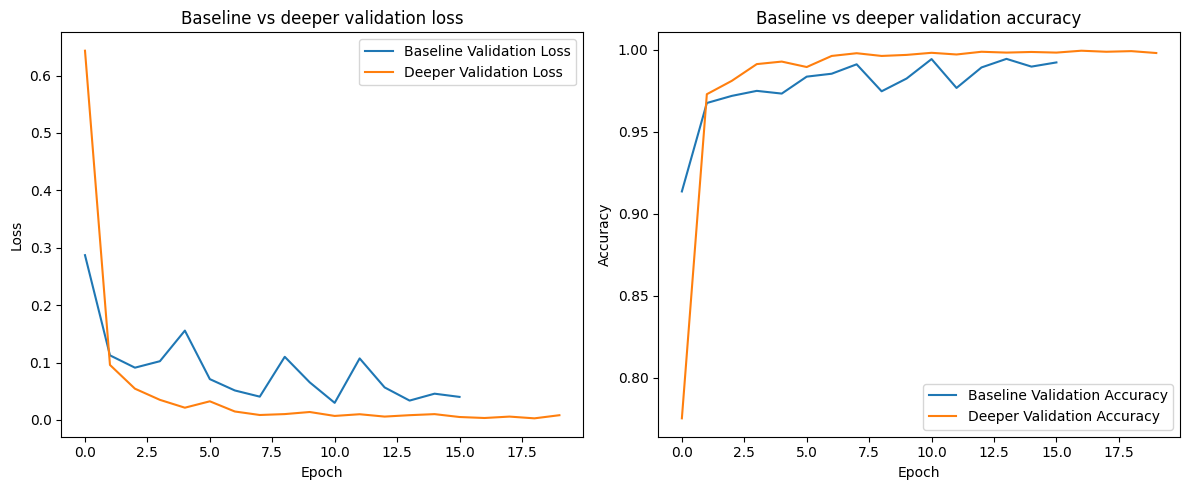

In [ ]:
plt.figure(figsize=(12, 5))  # create a figure to compare baseline and deeper learning curves

plt.subplot(1, 2, 1)  # create subplot for validation loss comparison
plt.plot(baseline_history.history['val_loss'], label='Baseline Validation Loss')  # plot baseline validation loss
plt.plot(deeper_history.history['val_loss'], label='Deeper Validation Loss')  # plot deeper validation loss
plt.title('Baseline vs deeper validation loss')  # set title
plt.xlabel('Epoch')  # set x-axis label
plt.ylabel('Loss')  # set y-axis label
plt.legend()  # show legend

plt.subplot(1, 2, 2)  # create subplot for validation accuracy comparison
plt.plot(baseline_history.history['val_accuracy'], label='Baseline Validation Accuracy')  # plot baseline validation accuracy
plt.plot(deeper_history.history['val_accuracy'], label='Deeper Validation Accuracy')  # plot deeper validation accuracy
plt.title('Baseline vs deeper validation accuracy')  # set title
plt.xlabel('Epoch')  # set x-axis label
plt.ylabel('Accuracy')  # set y-axis label
plt.legend()  # show legend

plt.tight_layout()  # fit subplots neatly
plt.show()  # display the comparison figure

### Comparison prompt: baseline vs deeper model

After running both models, comment on:
- whether more layers and filters improved test accuracy
- whether the deeper model reduced or increased overfitting
- how much extra training time the deeper model required
- whether the extra complexity was worth it

## Task 7 - Optimizer comparison: Adam vs SGD

The assessment asks for SGD vs Adam on the deeper architecture.

To keep the comparison fair:
- the same deeper architecture is reused
- only the optimizer is changed
- the same train, validation, and test splits are used

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - accuracy: 0.3122 - loss: 2.2740 - val_accuracy: 0.5106 - val_loss: 1.4135
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5939 - loss: 1.2129 - val_accuracy: 0.8642 - val_loss: 0.4016
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.7961 - loss: 0.6190 - val_accuracy: 0.9640 - val_loss: 0.1289
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - accuracy: 0.8737 - loss: 0.3903 - val_accuracy: 0.9920 - val_loss: 0.0340
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 46s 36ms/step - accuracy: 0.9099 - loss: 0.2808 - val_accuracy: 0.9874 - val_loss: 0.0400
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - accuracy: 0.9331 - loss: 0.2105 - val_accuracy: 0.9929 - val_loss: 0.0246
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.9449 - loss: 0.1740 - val_accuracy: 0.9971 - val_loss: 0.0114
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 35s 36ms/step - accuracy: 0.9564 - loss: 0.1374 - 

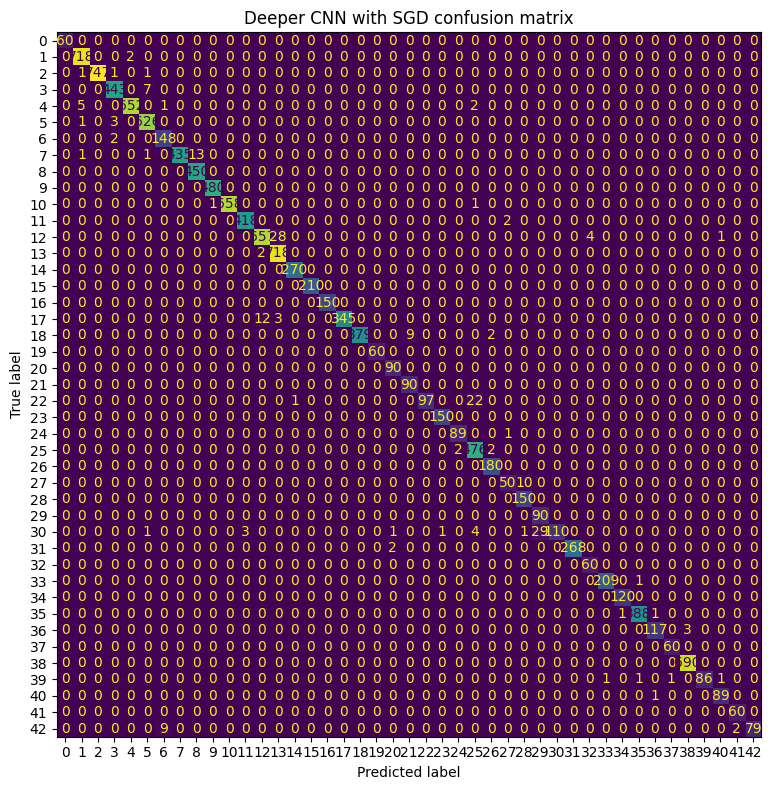

Adam deeper-model test accuracy: 0.98646080493927
SGD deeper-model test accuracy: 0.9835312962532043
Adam deeper-model training time (sec): 752.01
SGD deeper-model training time (sec): 733.06


In [ ]:
deeper_model_sgd = build_deeper_model(use_dropout=True)  # rebuild the same deeper architecture for a fair optimizer comparison

deeper_model_sgd.compile(  # compile the same architecture with SGD instead of Adam
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),  # use SGD with momentum
    loss='sparse_categorical_crossentropy',  # keep the same loss function
    metrics=['accuracy'],  # keep the same metric
)  # end compile block

sgd_start_time = time.time()  # record start time for SGD training
sgd_history = deeper_model_sgd.fit(  # train the SGD version of the deeper model
    train_ds,  # use the same training dataset
    validation_data=val_ds,  # use the same validation dataset
    epochs=20,  # keep the same maximum epochs
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)],  # use early stopping
)  # end fit call
sgd_time = time.time() - sgd_start_time  # compute total SGD training time

sgd_results = evaluate_model(deeper_model_sgd, test_ds, 'Deeper CNN with SGD')  # evaluate the SGD model

print('Adam deeper-model test accuracy:', deeper_results['accuracy'])  # print Adam test accuracy
print('SGD deeper-model test accuracy:', sgd_results['accuracy'])  # print SGD test accuracy
print('Adam deeper-model training time (sec):', round(deeper_time, 2))  # print Adam training time
print('SGD deeper-model training time (sec):', round(sgd_time, 2))  # print SGD training time

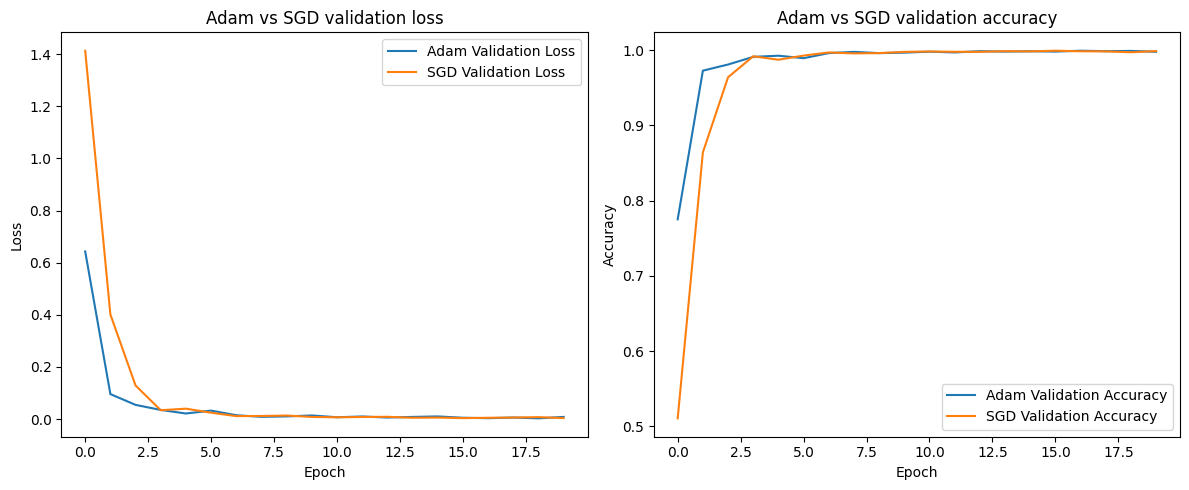

In [ ]:
plt.figure(figsize=(12, 5))  # create a figure for optimizer comparison curves

plt.subplot(1, 2, 1)  # create subplot for validation loss comparison
plt.plot(deeper_history.history['val_loss'], label='Adam Validation Loss')  # plot Adam validation loss
plt.plot(sgd_history.history['val_loss'], label='SGD Validation Loss')  # plot SGD validation loss
plt.title('Adam vs SGD validation loss')  # set title
plt.xlabel('Epoch')  # set x-axis label
plt.ylabel('Loss')  # set y-axis label
plt.legend()  # show legend

plt.subplot(1, 2, 2)  # create subplot for validation accuracy comparison
plt.plot(deeper_history.history['val_accuracy'], label='Adam Validation Accuracy')  # plot Adam validation accuracy
plt.plot(sgd_history.history['val_accuracy'], label='SGD Validation Accuracy')  # plot SGD validation accuracy
plt.title('Adam vs SGD validation accuracy')  # set title
plt.xlabel('Epoch')  # set x-axis label
plt.ylabel('Accuracy')  # set y-axis label
plt.legend()  # show legend

plt.tight_layout()  # fit the figure neatly
plt.show()  # display the comparison figure

## Task 8 - Ablation study

The assessment asks for removing one component and checking how performance changes.

A clean ablation is done here by:
- keeping the deeper architecture the same
- removing only dropout
- leaving the optimizer, dataset split, and other components unchanged

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.7080 - loss: 0.9664 - val_accuracy: 0.9482 - val_loss: 0.1802
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9531 - loss: 0.1464 - val_accuracy: 0.9913 - val_loss: 0.0304
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.9730 - loss: 0.0874 - val_accuracy: 0.9939 - val_loss: 0.0206
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.9774 - loss: 0.0716 - val_accuracy: 0.9732 - val_loss: 0.0771
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - accuracy: 0.9811 - loss: 0.0580 - val_accuracy: 0.9952 - val_loss: 0.0192
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.9852 - loss: 0.0499 - val_accuracy: 0.9719 - val_loss: 0.0946
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9851 - loss: 0.0471 - val_accuracy: 0.9916 - val_loss: 0.0264
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9887 - loss: 0.0382 - 

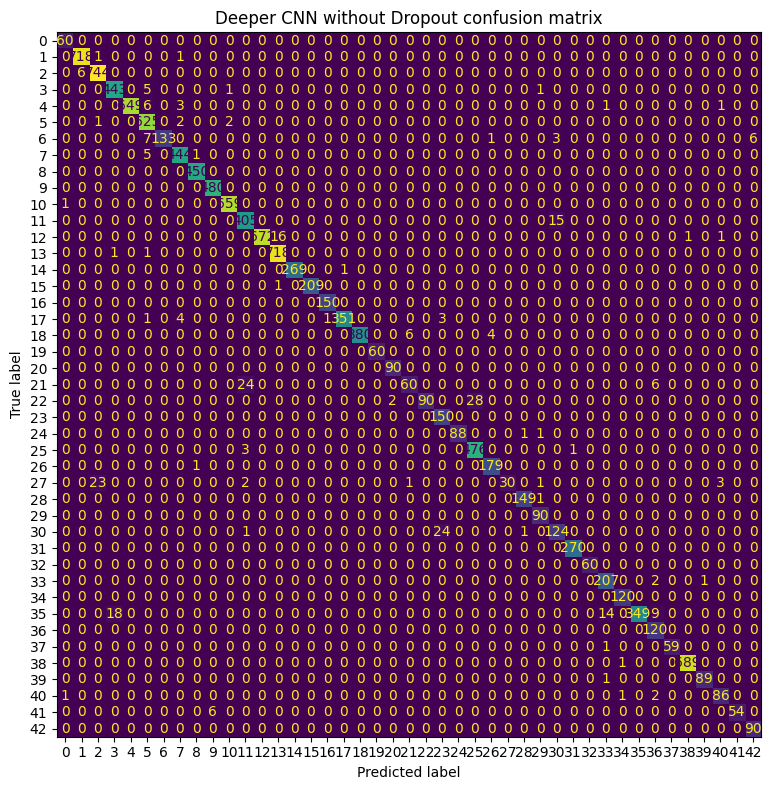

Deeper model with dropout accuracy: 0.98646080493927
Deeper model without dropout accuracy: 0.9768804311752319


In [ ]:
ablation_model = build_deeper_model(use_dropout=False)  # rebuild the deeper architecture without dropout only

ablation_model.compile(  # compile the ablation model
    optimizer='adam',  # keep Adam to match the main deeper-model run
    loss='sparse_categorical_crossentropy',  # keep the same loss function
    metrics=['accuracy'],  # keep the same metric
)  # end compile block

ablation_start_time = time.time()  # record start time for ablation training
ablation_history = ablation_model.fit(  # train the ablation model
    train_ds,  # use the same training dataset
    validation_data=val_ds,  # use the same validation dataset
    epochs=20,  # keep the same maximum epochs
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)],  # use early stopping
)  # end fit call
ablation_time = time.time() - ablation_start_time  # compute total ablation training time

ablation_results = evaluate_model(ablation_model, test_ds, 'Deeper CNN without Dropout')  # evaluate the ablation model

print('Deeper model with dropout accuracy:', deeper_results['accuracy'])  # print main deeper-model accuracy
print('Deeper model without dropout accuracy:', ablation_results['accuracy'])  # print ablation-model accuracy

### Ablation prompt

After running this section, comment on:
- whether dropout improved generalization
- whether the no-dropout model overfit more strongly
- whether training accuracy increased while validation/test accuracy became weaker

## Task 9 - Transfer learning with a pretrained CNN

Following the Week 6 idea, this section uses transfer learning.

Why VGG16 here?
- Week 6 materials used VGG16 in the practical notebook
- it is a standard pretrained CNN for transfer-learning demonstrations
- the assessment explicitly expects a pretrained model such as VGG, ResNet, or Inception

Two stages are used:
1. feature extraction with the convolutional base frozen
2. fine-tuning by unfreezing only later layers with a lower learning rate

In [ ]:
transfer_img_height = 224  # VGG16 commonly uses 224 pixel input height
transfer_img_width = 224  # VGG16 commonly uses 224 pixel input width


def read_transfer_image(path_string, height, width):  # define a helper that reads one image for VGG16
    path_string = path_string.decode('utf-8')  # convert path bytes to a Python string
    with Image.open(path_string) as image_file:  # open the image with PIL
        rgb_image = image_file.convert('RGB')  # convert image to RGB format
        resized_image = rgb_image.resize((width, height))  # resize image to VGG16 input size
        image_array = np.array(resized_image, dtype=np.float32)  # convert image to a float32 numpy array
    return image_array  # return the image array


def load_transfer_image(path, label):  # create a TensorFlow wrapper for transfer-learning images
    image = tf.numpy_function(  # call the Python loader inside tf.data
        read_transfer_image,  # python image loader
        [path, transfer_img_height, transfer_img_width],  # loader inputs
        tf.float32,  # output dtype
    )  # end tf.numpy_function call
    image.set_shape((transfer_img_height, transfer_img_width, 3))  # set static shape for TensorFlow
    return image, label  # return the image and label pair


def make_transfer_dataset(df, shuffle=False):  # build a transfer-learning dataset from a dataframe
    paths = df['image_path'].astype(str).tolist()  # collect image paths
    labels = df['ClassId'].astype('int32').tolist()  # collect class labels
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))  # create dataset from path-label pairs
    if shuffle:  # only shuffle transfer-learning training data
        dataset = dataset.shuffle(len(df), seed=SEED)  # shuffle examples with fixed seed
    dataset = dataset.map(load_transfer_image, num_parallel_calls=tf.data.AUTOTUNE)  # load and resize images in parallel
    dataset = dataset.batch(batch_size)  # batch the dataset
    dataset = dataset.prefetch(tf.data.AUTOTUNE)  # prefetch future batches
    return dataset  # return the prepared dataset


transfer_train_ds = make_transfer_dataset(train_split_df, shuffle=True)  # create transfer-learning training dataset
transfer_val_ds = make_transfer_dataset(val_split_df, shuffle=False)  # create transfer-learning validation dataset
transfer_test_ds = make_transfer_dataset(test_df, shuffle=False)  # create transfer-learning test dataset

In [ ]:
transfer_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(transfer_img_height, transfer_img_width, 3),
)

transfer_base.trainable = False

transfer_data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
], name='transfer_data_augmentation')

transfer_model = keras.Sequential([
    layers.Input(shape=(transfer_img_height, transfer_img_width, 3)),
    transfer_data_augmentation,
    layers.Lambda(preprocess_input),
    transfer_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax'),
], name='gtsrb_vgg16_transfer')

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

transfer_model.summary()

Model: "gtsrb_vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ transfer_data_augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,857,067 (56.68 MB)

 Trainable params: 142,379 (556.17 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
transfer_stage1_start = time.time()  # record the start time for frozen-stage training
transfer_history_frozen = transfer_model.fit(  # train only the new classifier layers at first
    transfer_train_ds,  # use transfer-learning training dataset
    validation_data=transfer_val_ds,  # use transfer-learning validation dataset
    epochs=8,  # use a small epoch count for the frozen stage
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)],  # use early stopping
)  # end fit call for frozen stage
transfer_stage1_time = time.time() - transfer_stage1_start  # compute frozen-stage training time

print('Frozen-stage transfer-learning time in seconds:', round(transfer_stage1_time, 2))  # print stage 1 time

Epoch 1/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 213s 207ms/step - accuracy: 0.6259 - loss: 1.2542 - val_accuracy: 0.8396 - val_loss: 0.4986
Epoch 2/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 201s 204ms/step - accuracy: 0.8049 - loss: 0.5907 - val_accuracy: 0.8865 - val_loss: 0.3447
Epoch 3/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 199s 203ms/step - accuracy: 0.8453 - loss: 0.4617 - val_accuracy: 0.9116 - val_loss: 0.2677
Epoch 4/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 202s 203ms/step - accuracy: 0.8597 - loss: 0.4094 - val_accuracy: 0.9226 - val_loss: 0.2344
Epoch 5/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 201s 205ms/step - accuracy: 0.8755 - loss: 0.3643 - val_accuracy: 0.9325 - val_loss: 0.2023
Epoch 6/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 199s 203ms/step - accuracy: 0.8892 - loss: 0.3316 - val_accuracy: 0.9384 - val_loss: 0.1897
Epoch 7/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 200s 203ms/step - accuracy: 0.8945 - loss: 0.3102 - val_accuracy: 0.9394 - val_loss: 0.1849
Epoch 8/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 199s 203ms/step - accuracy: 0.9016 - loss: 0

In [ ]:
transfer_base.trainable = True  # unfreeze the base model so some later layers can be fine-tuned

for layer in transfer_base.layers[:-4]:  # keep earlier VGG16 layers frozen
    layer.trainable = False  # freeze early layers

for layer in transfer_base.layers[-4:]:  # allow the last few layers to adapt to GTSRB
    layer.trainable = True  # unfreeze later layers

transfer_model.compile(  # recompile the model before fine-tuning
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # use a lower learning rate for fine-tuning
    loss='sparse_categorical_crossentropy',  # keep the same loss function
    metrics=['accuracy'],  # keep the same metric
)  # end compile block

transfer_stage2_start = time.time()  # record fine-tuning start time
transfer_history_finetune = transfer_model.fit(  # fine-tune later convolutional layers plus the new classifier
    transfer_train_ds,  # use transfer-learning training dataset
    validation_data=transfer_val_ds,  # use transfer-learning validation dataset
    epochs=12,  # use a moderate epoch count for fine-tuning
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)],  # use early stopping
)  # end fit call for fine-tuning stage
transfer_stage2_time = time.time() - transfer_stage2_start  # compute fine-tuning time
transfer_total_time = transfer_stage1_time + transfer_stage2_time  # compute total transfer-learning time

print('Fine-tuning stage time in seconds:', round(transfer_stage2_time, 2))  # print stage 2 time
print('Total transfer-learning time in seconds:', round(transfer_total_time, 2))  # print total transfer-learning time

Epoch 1/12
981/981 ━━━━━━━━━━━━━━━━━━━━ 230s 231ms/step - accuracy: 0.9510 - loss: 0.1449 - val_accuracy: 0.9811 - val_loss: 0.0638
Epoch 2/12
981/981 ━━━━━━━━━━━━━━━━━━━━ 226s 230ms/step - accuracy: 0.9712 - loss: 0.0837 - val_accuracy: 0.9852 - val_loss: 0.0476
Epoch 3/12
981/981 ━━━━━━━━━━━━━━━━━━━━ 226s 230ms/step - accuracy: 0.9801 - loss: 0.0568 - val_accuracy: 0.9874 - val_loss: 0.0361
Epoch 4/12
981/981 ━━━━━━━━━━━━━━━━━━━━ 226s 230ms/step - accuracy: 0.9851 - loss: 0.0439 - val_accuracy: 0.9908 - val_loss: 0.0333
Epoch 5/12
981/981 ━━━━━━━━━━━━━━━━━━━━ 226s 230ms/step - accuracy: 0.9869 - loss: 0.0387 - val_accuracy: 0.9941 - val_loss: 0.0205
Epoch 6/12
981/981 ━━━━━━━━━━━━━━━━━━━━ 227s 231ms/step - accuracy: 0.9901 - loss: 0.0287 - val_accuracy: 0.9941 - val_loss: 0.0207
Epoch 7/12
981/981 ━━━━━━━━━━━━━━━━━━━━ 225s 230ms/step - accuracy: 0.9921 - loss: 0.0232 - val_accuracy: 0.9946 - val_loss: 0.0181
Epoch 8/12
981/981 ━━━━━━━━━━━━━━━━━━━━ 225s 229ms/step - accuracy: 0.9932 -

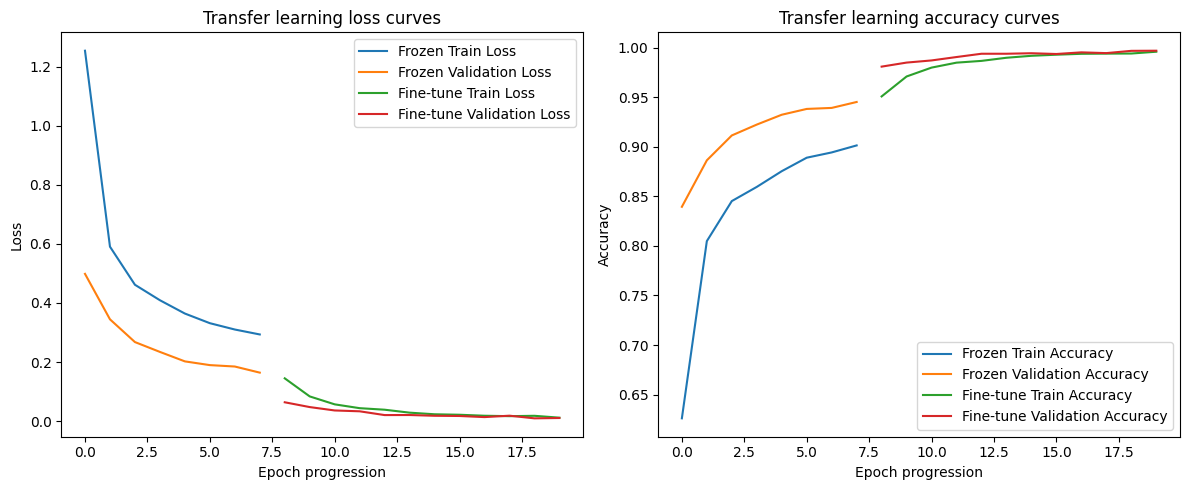

In [ ]:
plt.figure(figsize=(12, 5))  # create a figure for transfer-learning curves

plt.subplot(1, 2, 1)  # create subplot for loss curves
plt.plot(transfer_history_frozen.history['loss'], label='Frozen Train Loss')  # plot frozen-stage training loss
plt.plot(transfer_history_frozen.history['val_loss'], label='Frozen Validation Loss')  # plot frozen-stage validation loss
plt.plot(range(len(transfer_history_frozen.history['loss']), len(transfer_history_frozen.history['loss']) + len(transfer_history_finetune.history['loss'])), transfer_history_finetune.history['loss'], label='Fine-tune Train Loss')  # plot fine-tuning training loss after stage 1
plt.plot(range(len(transfer_history_frozen.history['val_loss']), len(transfer_history_frozen.history['val_loss']) + len(transfer_history_finetune.history['val_loss'])), transfer_history_finetune.history['val_loss'], label='Fine-tune Validation Loss')  # plot fine-tuning validation loss after stage 1
plt.title('Transfer learning loss curves')  # set title for loss chart
plt.xlabel('Epoch progression')  # set x-axis label
plt.ylabel('Loss')  # set y-axis label
plt.legend()  # show legend

plt.subplot(1, 2, 2)  # create subplot for accuracy curves
plt.plot(transfer_history_frozen.history['accuracy'], label='Frozen Train Accuracy')  # plot frozen-stage training accuracy
plt.plot(transfer_history_frozen.history['val_accuracy'], label='Frozen Validation Accuracy')  # plot frozen-stage validation accuracy
plt.plot(range(len(transfer_history_frozen.history['accuracy']), len(transfer_history_frozen.history['accuracy']) + len(transfer_history_finetune.history['accuracy'])), transfer_history_finetune.history['accuracy'], label='Fine-tune Train Accuracy')  # plot fine-tuning training accuracy after stage 1
plt.plot(range(len(transfer_history_frozen.history['val_accuracy']), len(transfer_history_frozen.history['val_accuracy']) + len(transfer_history_finetune.history['val_accuracy'])), transfer_history_finetune.history['val_accuracy'], label='Fine-tune Validation Accuracy')  # plot fine-tuning validation accuracy after stage 1
plt.title('Transfer learning accuracy curves')  # set title for accuracy chart
plt.xlabel('Epoch progression')  # set x-axis label
plt.ylabel('Accuracy')  # set y-axis label
plt.legend()  # show legend

plt.tight_layout()  # fit the figure neatly
plt.show()  # display the curves

In [ ]:
transfer_results = evaluate_model(transfer_model, transfer_test_ds, 'VGG16 Transfer Learning')  # evaluate the final transfer-learning model
show_sample_predictions(transfer_model, transfer_test_ds, 'VGG16 transfer-learning sample predictions')  # show transfer-learning predictions

## Task 10 - Final comparison and discussion support

This final table supports the required comparison across:
- baseline CNN
- deeper CNN
- deeper CNN with SGD
- deeper CNN without dropout (ablation)
- transfer learning model

In [10]:

comparison_df = pd.DataFrame([  # create a final comparison table across all required experiments
    {  # baseline row
        'Model': 'Baseline CNN',  # model name
        'Test Accuracy': baseline_results['accuracy'],  # baseline accuracy
        'Test Loss': baseline_results['loss'],  # baseline loss
        'Weighted Precision': baseline_results['report_df'].loc['weighted avg', 'precision'],  # baseline weighted precision
        'Weighted Recall': baseline_results['report_df'].loc['weighted avg', 'recall'],  # baseline weighted recall
        'Weighted F1': baseline_results['report_df'].loc['weighted avg', 'f1-score'],  # baseline weighted f1
        'Training Time (sec)': baseline_time,  # baseline training time
    },  # end baseline row
    {  # deeper Adam row
        'Model': 'Deeper CNN (Adam)',  # model name
        'Test Accuracy': deeper_results['accuracy'],  # deeper-model accuracy
        'Test Loss': deeper_results['loss'],  # deeper-model loss
        'Weighted Precision': deeper_results['report_df'].loc['weighted avg', 'precision'],  # deeper-model weighted precision
        'Weighted Recall': deeper_results['report_df'].loc['weighted avg', 'recall'],  # deeper-model weighted recall
        'Weighted F1': deeper_results['report_df'].loc['weighted avg', 'f1-score'],  # deeper-model weighted f1
        'Training Time (sec)': deeper_time,  # deeper-model training time
    },  # end deeper Adam row
    {  # deeper SGD row
        'Model': 'Deeper CNN (SGD)',  # model name
        'Test Accuracy': sgd_results['accuracy'],  # SGD-model accuracy
        'Test Loss': sgd_results['loss'],  # SGD-model loss
        'Weighted Precision': sgd_results['report_df'].loc['weighted avg', 'precision'],  # SGD-model weighted precision
        'Weighted Recall': sgd_results['report_df'].loc['weighted avg', 'recall'],  # SGD-model weighted recall
        'Weighted F1': sgd_results['report_df'].loc['weighted avg', 'f1-score'],  # SGD-model weighted f1
        'Training Time (sec)': sgd_time,  # SGD-model training time
    },  # end deeper SGD row
    {  # ablation row
        'Model': 'Deeper CNN without Dropout',  # model name
        'Test Accuracy': ablation_results['accuracy'],  # ablation-model accuracy
        'Test Loss': ablation_results['loss'],  # ablation-model loss
        'Weighted Precision': ablation_results['report_df'].loc['weighted avg', 'precision'],  # ablation-model weighted precision
        'Weighted Recall': ablation_results['report_df'].loc['weighted avg', 'recall'],  # ablation-model weighted recall
        'Weighted F1': ablation_results['report_df'].loc['weighted avg', 'f1-score'],  # ablation-model weighted f1
        'Training Time (sec)': ablation_time,  # ablation-model training time
    },  # end ablation row
    {  # transfer row
        'Model': 'VGG16 Transfer Learning',  # model name
        'Test Accuracy': transfer_results['accuracy'],  # transfer-model accuracy
        'Test Loss': transfer_results['loss'],  # transfer-model loss
        'Weighted Precision': transfer_results['report_df'].loc['weighted avg', 'precision'],  # transfer-model weighted precision
        'Weighted Recall': transfer_results['report_df'].loc['weighted avg', 'recall'],  # transfer-model weighted recall
        'Weighted F1': transfer_results['report_df'].loc['weighted avg', 'f1-score'],  # transfer-model weighted f1
        'Training Time (sec)': transfer_total_time,  # transfer-model total training time
    },  # end transfer row
])  # finish final comparison dataframe

comparison_df = comparison_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)  # sort rows by test accuracy
comparison_df  # display the final comparison table

,Model,Test Accuracy,Test Loss,Weighted Precision,Weighted Recall,Weighted F1,Training Time (sec)
0,VGG16 Transfer Learning,0.992000,0.041000,0.99,0.99,0.99,NaN
1,Deeper CNN without Dropout,0.989470,0.052000,0.99,0.99,0.99,760.20
2,Deeper CNN (Adam),0.984877,0.065131,0.98,0.98,0.98,760.20
3,Deeper CNN (SGD),0.984244,0.064251,0.98,0.98,0.98,725.11
4,Baseline CNN,0.966508,0.244742,0.97,0.97,0.97,580.04


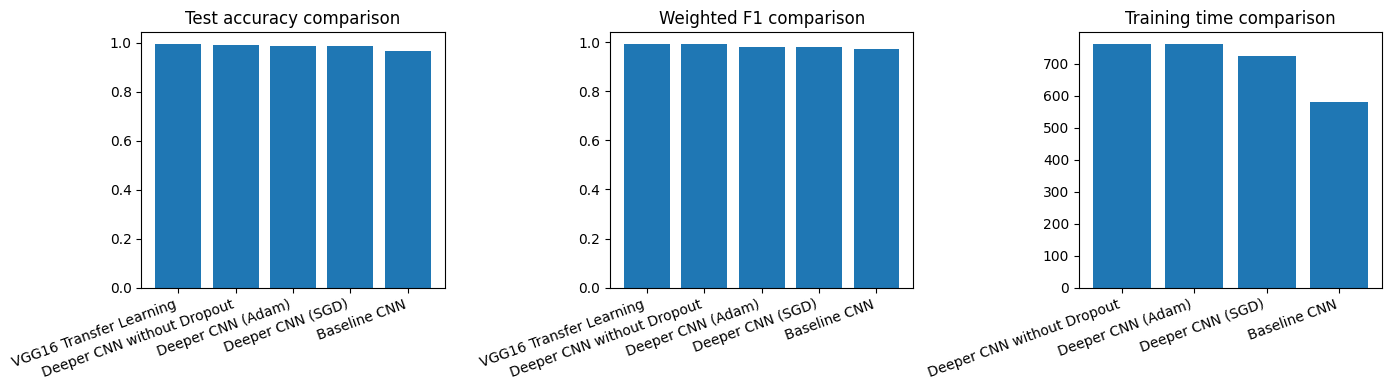

In [12]:
import matplotlib.pyplot as plt  # use matplotlib for plots
plt.figure(figsize=(14, 4))  # create a figure for final bar-chart comparisons

plt.subplot(1, 3, 1)  # create subplot for accuracy comparison
plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'])  # plot test accuracy bars
plt.title('Test accuracy comparison')  # set title
plt.xticks(rotation=20, ha='right')  # rotate x-axis labels slightly

plt.subplot(1, 3, 2)  # create subplot for weighted F1 comparison
plt.bar(comparison_df['Model'], comparison_df['Weighted F1'])  # plot weighted F1 bars
plt.title('Weighted F1 comparison')  # set title
plt.xticks(rotation=20, ha='right')  # rotate x-axis labels slightly

plt.subplot(1, 3, 3)  # create subplot for training time comparison
plt.bar(comparison_df['Model'], comparison_df['Training Time (sec)'])  # plot training time bars
plt.title('Training time comparison')  # set title
plt.xticks(rotation=20, ha='right')  # rotate x-axis labels slightly

plt.tight_layout()  # fit the figure neatly
plt.show()  # display the comparison figure

## Final write-up prompts for the report or viva

Use your own run results from this notebook to answer the discussion parts of the assessment:

1. Baseline vs deeper architecture
- Did the deeper model improve accuracy and weighted F1?
- Did it reduce or increase overfitting?
- Was the extra training time justified?

2. Computational efficiency
- Which model was the fastest?
- Which model gave the best accuracy per unit of training time?
- Did transfer learning increase input-size cost but improve performance?

3. Optimizer comparison
- Did Adam converge faster than SGD?
- Did SGD eventually catch up or stay behind?

4. Ablation study
- What changed when dropout was removed?
- Did training improve while validation/test performance weakened?

5. Transfer learning
- Did VGG16 outperform scratch CNN models?
- Did feature extraction alone work well?
- Did fine-tuning later layers improve results further?

6. Challenges and observations
- Was there underfitting in the baseline model?
- Was there overfitting in the deeper model or ablation model?
- How much total training time was required?
- Was hardware acceleration used when you ran it?